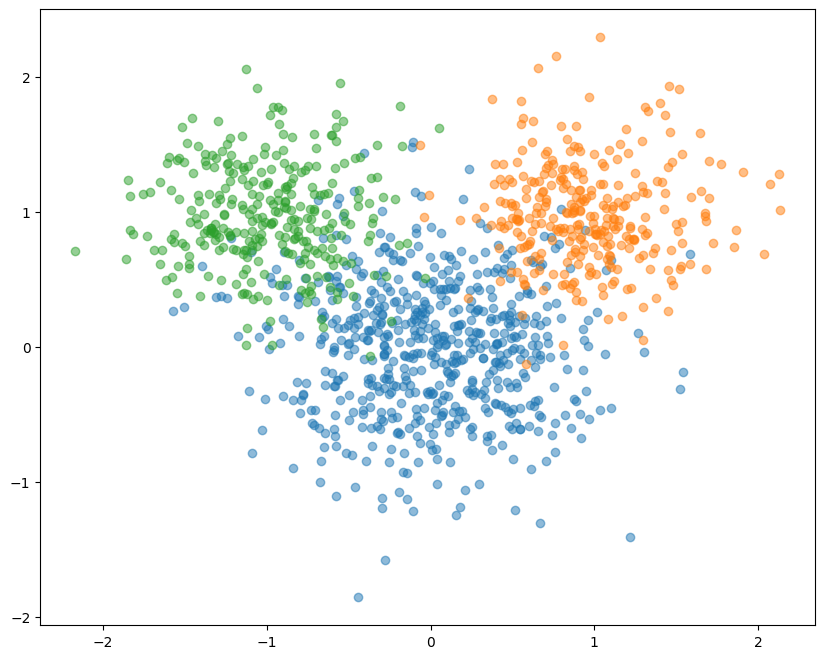

In [170]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(12)
mean1 = np.array([0.0, 0.0])
cov1 = np.array([[0.25, 0.0],
                 [0.0, 0.25]])
data1 = np.random.multivariate_normal(mean1, cov1, 600)

mean2 = np.array([1.0, 1.0])
cov2 = np.array([[0.15, 0.0],
                 [0.0, 0.15]])
data2 = np.random.multivariate_normal(mean2, cov2, 300)

mean3 = np.array([-1.0, 1.0])
cov3 = np.array([[0.15, 0.0],
                 [0.0, 0.15]])
data3 = np.random.multivariate_normal(mean3, cov3, 300)

data_X = np.vstack([data1, data2, data3])

plt.figure(figsize=(10, 8))
plt.scatter(data1[:,0], data1[:,1], alpha=0.5)
plt.scatter(data2[:,0], data2[:,1], alpha=0.5)
plt.scatter(data3[:,0], data3[:,1], alpha=0.5)

# Combine all data
data_X = np.vstack([data1, data2, data3])
N, d = data_X.shape




**E-Step**

Recall, that in this step
$$
  q(\mathbf Z ) = p(\mathbf Z \mid \mathbf X, \theta^{(old)}).
$$

In this particular $E-step$, we fix the current parameter values $\theta^{(old)}$ and compute the posterior (responsibility) for each latent variable:
$$
  \gamma_{n, k} = p(z_n = k \mid x_n, \theta^{(old)}) = \frac{\pi_k^{(old)}\mathfrak{n}_{\mu_k^{(old)}, \Sigma_k^{(old)}}(x_n)}{\sum_{l = 1}^K [\pi_l^{(old)}\mathfrak{n}_{\mu_l^{(old)}, \Sigma_l^{(old)}}(x_l)]}.
$$

This step effectively infers the latent membership probabilities for each data point given the current guess of the mixture parameters.

**M-Step**

We fix $\mathbf Z$ distribution, which equals to fixing responsibilities $\gamma_{n, k}$. Then we update parameters $\{\pi_k, \mu_k, \Sigma_k\}$ to maximize $\mathbb{E}_q\log p(\mathbf X, \mathbf Z \mid \theta)$.

Effectively, we are maximizing
$$
  \mathbb{E}_q\log p(\mathbf X, \mathbf Z \mid \theta) = \sum_{n = 1}^N \sum_{k = 1}^K \gamma_{n, k}\big[\log \pi_k - \frac{1}{2} \log 2\pi - \frac{1}{2}\log |\Sigma_k| - \frac{1}{2}(x_n - \mu_k)^T\Sigma_k^{-1}(x_n - \mu_k)\big].
$$

We have $\sum_{k = 1}^K \pi_k = 1$, so
$$
  L(\pi_k, \lambda) = \sum_{n = 1}^N \gamma_{n, k} \log \pi_k + \lambda\big(\sum_{k = 1}^K \pi_k
 - 1\big)
$$
and
$$
  \partial_{\pi_k}L(\pi_k, \lambda) = \frac{1}{\pi_k}\sum_{n = 1}^N \gamma_{n, k} + \lambda = 0 \quad ⟺ \quad \pi_k = -\frac{1}{\lambda}\sum_{n = 1}^N \gamma_{n, k}.
$$
From that, using $\sum_{k = 1}^K \gamma_{n, k} = 1$, we get
$$
   1 = -\frac{N}{\lambda} \quad ⟺ \quad \lambda = -N
$$
and
$$
  \hat \pi_k = \frac{1}{N} \sum_{n = 1}^N \gamma_{n, k}.
$$
Next, as $\Sigma_k^{-1}$ is symmetric, then
$$
  \partial_{\mu_k}l(\mu_k) = \sum_{n = 1}^N\gamma_{n, k}\Sigma_k^{-1}(x_n - \mu_k) = 0
$$
iff
$$
  \sum_{n = 1}^N\gamma_{n, k}x_n = \sum_{n = 1}^N\gamma_{n, k}\mu_k.
$$
That means
$$
  \hat \mu_k = \frac{\sum_{n = 1}^N\gamma_{n, k}x_n}{\sum_{n = 1}^N\gamma_{n, k}}.
$$

Finally, without loss of generality, assuming that $\Sigma_k^{-1} = \mathrm{diag}(\lambda_{1, k}, \dots, \lambda_{d, k})$
$$
  l(\Sigma_k) = -\frac{1}{2}\sum_{l = 1}^d \sum_{n = 1}^N\gamma_{n, k} \big(-\log \lambda_{l, k} + \lambda_{l, k}(x_{n, l} - \mu_{k, l})^2 \big)
$$
and
$$
  \partial_{\lambda_{l, k}}l(\lambda_{l, k}) = -\frac{1}{2}\sum_{n = 1}^N \gamma_{n, k}\big(-\frac{1}{\lambda_{l, k}} + (x_{n, l} - \mu_{k, l})^2\big) = 0
$$
iff
$$
  \frac{1}{\lambda_{l, k}} = \frac{\sum_{n = 1}^N \gamma_{n, k}(x_{n, l} - \mu_{k, l})^2}{\sum_{n = 1}^N \gamma_{n, k}}.
$$
We get
$$
  \hat \Sigma_k = \frac{\sum_{n = 1}^N \gamma_{n, k}(x_n - \mu_k)(x_n - \mu_k)^T}{\sum_{n = 1}^N \gamma_{n, k}}.
$$

In [171]:
from scipy.stats import multivariate_normal
npdf = multivariate_normal.pdf

K = 3

np.random.seed(13)
#Initial mixture parameters
pi = np.ones(K) / K
mu = np.random.randn(K, d)
Sigma = np.array([np.eye(d) for _ in range(K)])

#Functions for E-Step and M-Step
def e_step(data, pi, mu, Sigma):
  N = data.shape[0]
  K = len(pi)
  resp = np.zeros((N, K))

  for k in range(K):
    resp[:, k] = pi[k] * npdf(data, mean=mu[k], cov=Sigma[k])

  resp /= resp.sum(axis=1)[:, None]
  return resp

def m_step(data, resp):
  N, d = data.shape
  K = resp.shape[1]
  resp_sums = resp.sum(axis=0)
  pi_hat = resp_sums / N
  mu_hat = (resp.T @ data) / resp_sums.reshape(-1, 1)

  sigma_hat = np.zeros((K, d, d))
  for k in range(K):
    diff = data - mu_hat[k]
    weighted = diff * resp[:, k].reshape(-1, 1)
    sigma_hat[k] = (weighted.T @ diff) / resp_sums[k]

  return pi_hat, mu_hat, sigma_hat


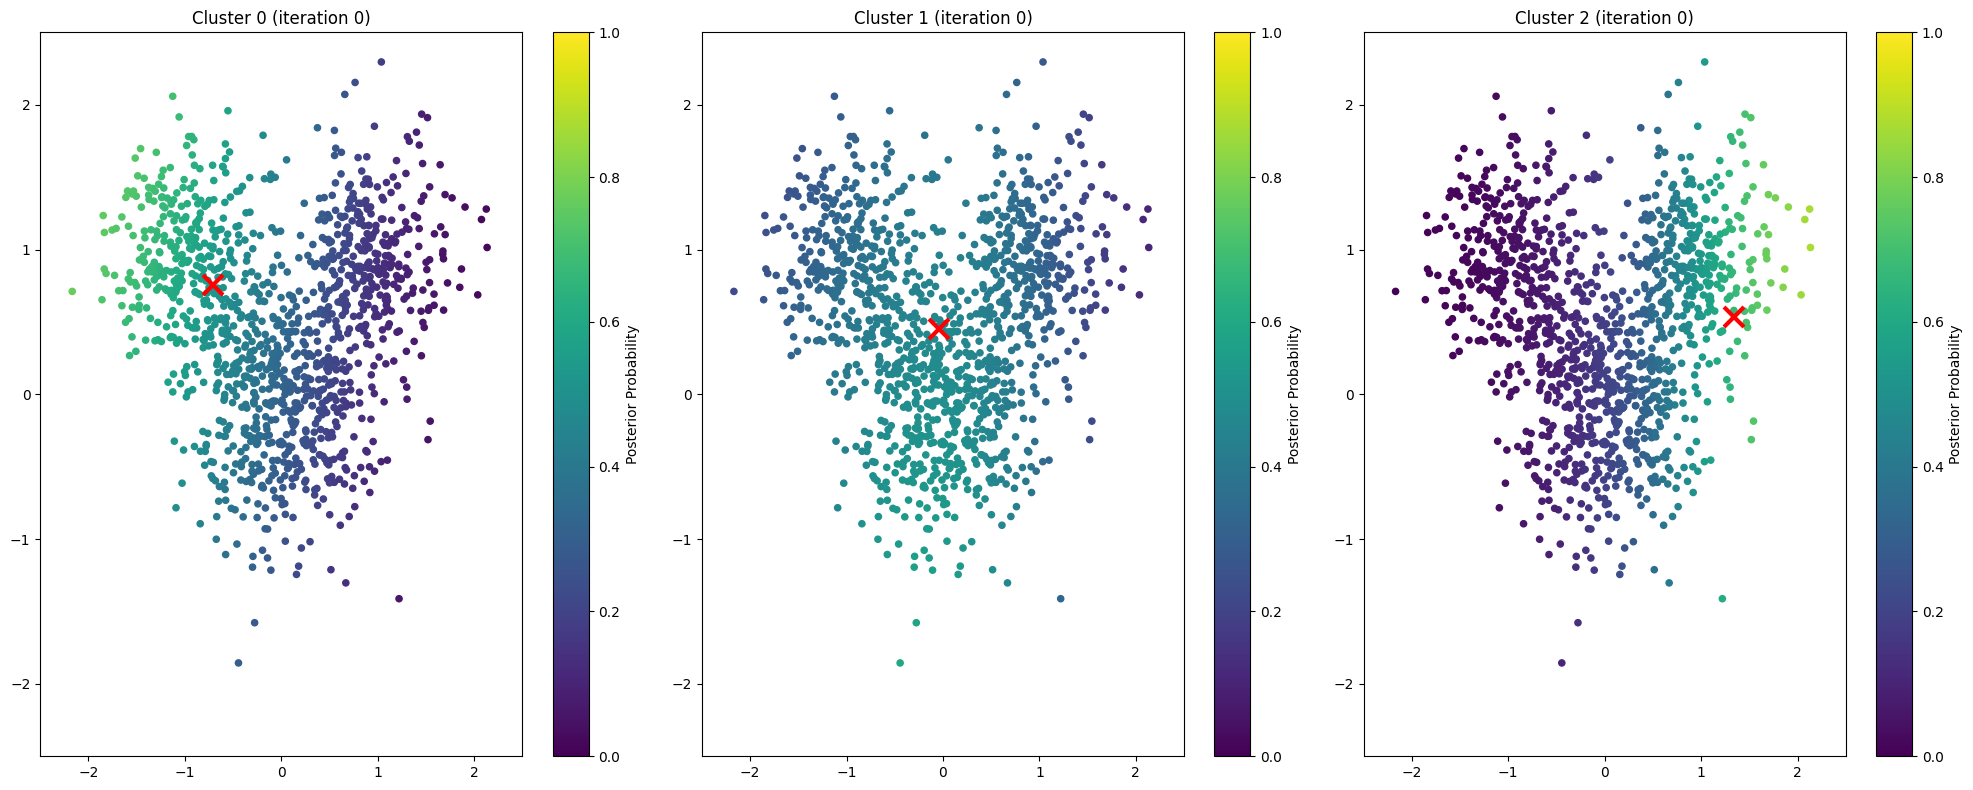

In [172]:
# Precompute figure, axes, and placeholders for scatter plots and cluster centers
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# We'll create one scatter per cluster:
scatters = []
center_plots = []

# Initialize the responsibilities (before first iteration) just for plotting the colors
resp_init = e_step(data_X, pi, mu, Sigma)

for k in range(K):
    # Scatter for the data with color = responsibilities for cluster k
    sc = axes[k].scatter(data_X[:, 0], data_X[:, 1],
                         c=resp_init[:, k], cmap='viridis',
                         s=20, vmin=0, vmax=1)

    scatters.append(sc)

    # Plot for the cluster center: "X" in red
    cp, = axes[k].plot(mu[k,0], mu[k,1], 'rx', markersize=14, mew=3)
    center_plots.append(cp)

    axes[k].set_title(f'Cluster {k} (iteration 0)')
    axes[k].set_xlim([-2.5, 2.5])
    axes[k].set_ylim([-2.5, 2.5])

    # Add a colorbar for each subplot
    cbar = fig.colorbar(sc, ax=axes[k])
    cbar.set_label('Posterior Probability')

plt.tight_layout()
plt.show()

In [173]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

iterations = 60  # number of EM iterations (frames in the animation)
    #In 60 iterations the EM converges

# ----------------------------------------------------------------------
# SECTION 5: Define the update function for animation
# ----------------------------------------------------------------------
def init():
    # Nothing special needed for init
    return scatters + center_plots

def animate(frame):
    global pi, mu, Sigma

    # Perform one E-step + M-step
    resp = e_step(data_X, pi, mu, Sigma)
    pi, mu, Sigma = m_step(data_X, resp)

    # Update the scatter colors & cluster center positions
    for k in range(K):
        # update scatter color array
        scatters[k].set_array(resp[:, k])
        # update center plot
        center_plots[k].set_data([mu[k,0]], [mu[k,1]])
        axes[k].set_title(f'Cluster {k} (iteration {frame+1})')
    return scatters + center_plots

anim = FuncAnimation(fig, animate, frames=iterations,
                     init_func=init, blit=False, interval=120)

# ----------------------------------------------------------------------
# SECTION 6: Display the animation
# ----------------------------------------------------------------------
# If you're in a Jupyter/Colab environment, you can display the animation inline:
HTML(anim.to_html5_video())


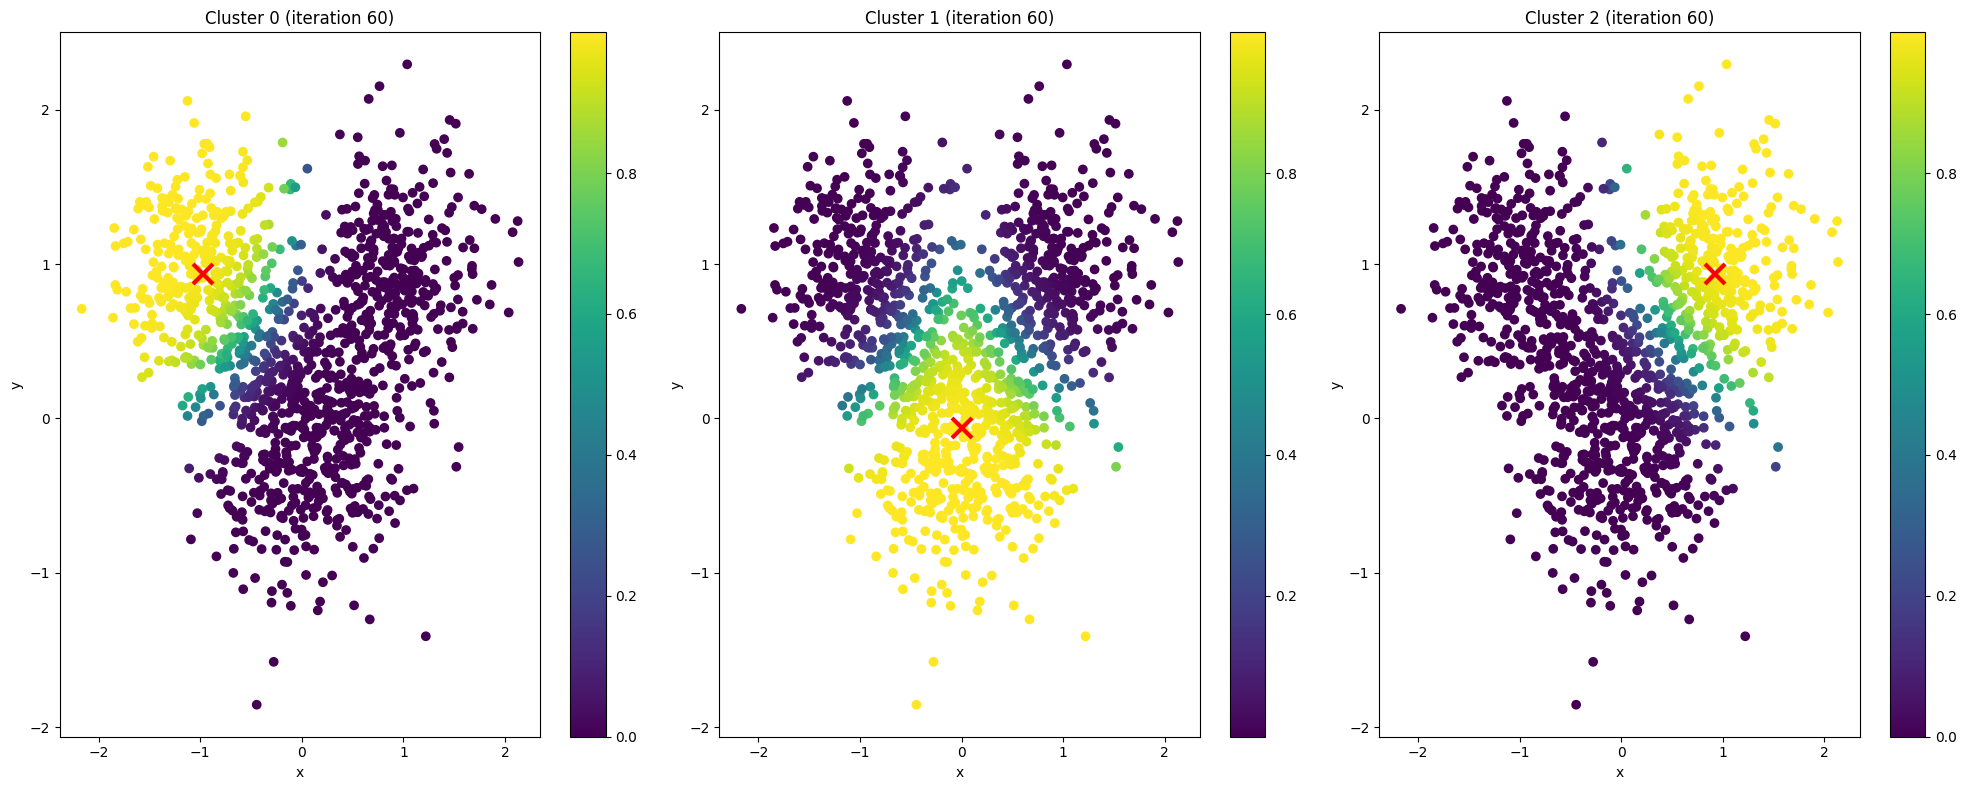

In [174]:
resp_final = e_step(data_X, pi, mu, Sigma)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for k in range(K):
    sc = axes[k].scatter(data_X[:,0], data_X[:,1], c=resp_final[:, k], cmap='viridis')
    axes[k].set_title(f'Cluster {k} (iteration {iterations})')
    axes[k].set_xlabel('x')
    axes[k].set_ylabel('y')
    # Plot for the cluster center: "X" in red
    cp = axes[k].plot(mu[k,0], mu[k,1], 'rx', markersize=14, mew=3)
    # Add a colorbar
    plt.colorbar(sc, ax=axes[k])

plt.tight_layout()
plt.show()

**Primary Question**

**How can we visualize the decision boundary for attributing a new (unlabeled) point to one of the GMM clusters?**

**Secondary Question**

**If we didn't know the number of clusters in advance, how could we decide on a suitable K for the clustering algorithm?**

**Primary Question**

What we essentially want to do is to create a dense grid of points and for all of them compute responsibiliteis to estimated $\pi_k, \mu_k, \Sigma_k$ values. Then we want to assign the point to the cluster with highest responsibility i.e.
$$
  k^* = \mathrm{argmax​}_kp(z = k \mid x) = \mathrm{argmax}_k\pi_k \mathfrak{n}_{\mu_k, \Sigma_k}(x).
$$


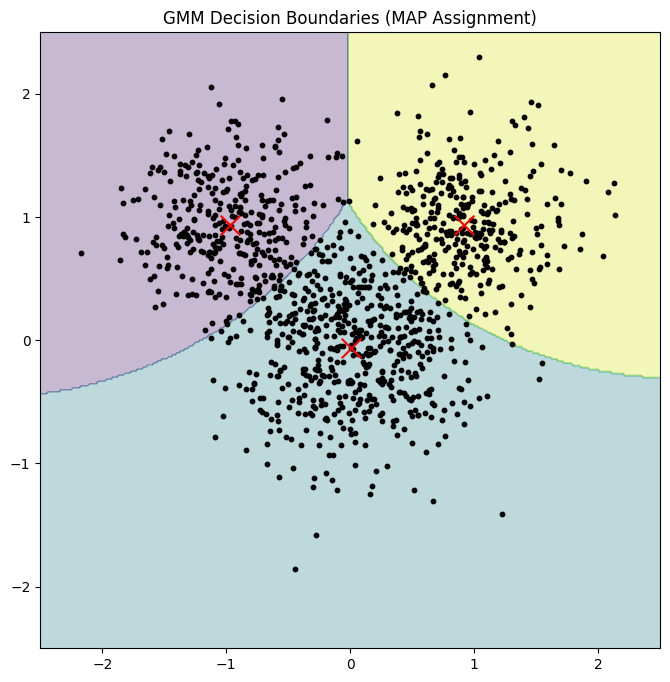

In [175]:
xx, yy = np.meshgrid(
    np.linspace(-2.5, 2.5, 300),
    np.linspace(-2.5, 2.5, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

resp_grid = e_step(grid, pi, mu, Sigma)

# assign cluster with highest posterior probability
cluster_assignment = np.argmax(resp_grid, axis=1)
Z = cluster_assignment.reshape(xx.shape)

plt.figure(figsize=(8,8))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# overlay original data
plt.scatter(data_X[:,0], data_X[:,1], c='black', s=10)

# plot cluster centers
plt.scatter(mu[:,0], mu[:,1], c='red', marker='x', s=200)

plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.title("GMM Decision Boundaries (MAP Assignment)")
plt.show()

Boundaries are curved becouse depend on gaussian - elpitical - distribution.

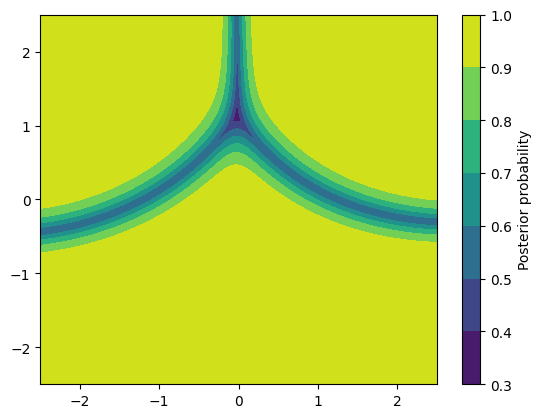

In [176]:
confidence = np.max(resp_grid, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, confidence, cmap='viridis')
plt.colorbar(label="Posterior probability")

Points that lie near the decision boundaries have lower certainty in their cluster assignment, which is expected. In these regions, the posterior probabilities of multiple clusters are similar, meaning that small changes in the model parameters can significantly affect the assignment.

This also explains why the posterior probability of a point may change even when the center of its most likely cluster remains stationary. The posterior probability depends not only on the parameters of that cluster but also on the parameters of the other clusters. Therefore, when other cluster centers move during the EM updates, they can alter the relative likelihoods and consequently change the posterior probabilities for nearby points.

**Secondary Question**



We will use K-Means algorithm and data proveided for PCA Assignment.

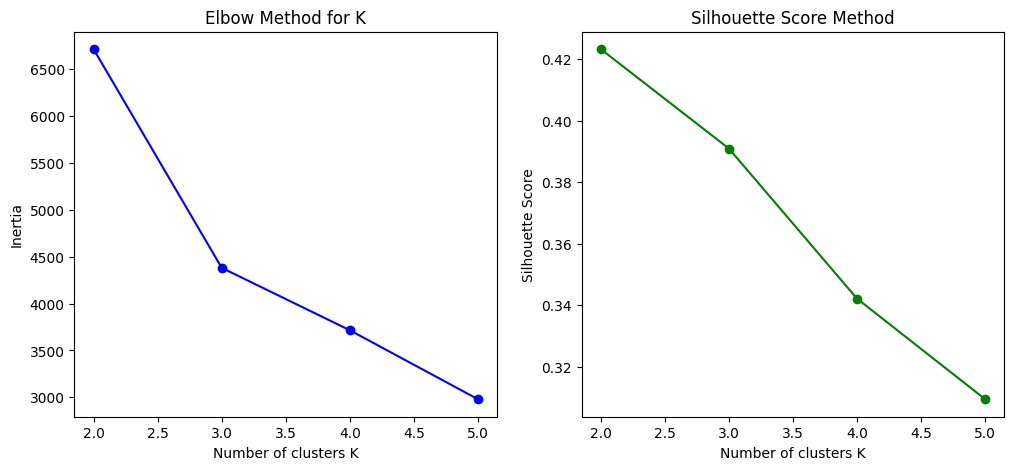

Inertia percentage drop
0.3472995747557409
0.15189838288862892
0.19793407976751928
Silhouette score percentage drop
0.0764129580827511
0.12487881180371713
0.09557465912221703


In [177]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

url = "https://raw.githubusercontent.com/SzymonNowakowski/Machine-Learning-2025L/master/PCA_three_clusters_data.csv"
df = pd.read_csv(url)

X, _ = df.drop(columns='class').to_numpy(), df['class'].to_numpy()
m, n = X.shape
K_range = tuple(range(2, 6))
models = tuple(
    (
        KMeans(n_clusters=k, random_state=0, n_init="auto").fit(X)
        for k in K_range
    )
)

inertia_values = tuple((model.inertia_ for model in models))
silhouette_scores = tuple((silhouette_score(X, model.labels_) for model in models))

# Plot Inertia (Elbow Method)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, inertia_values, 'o-', color='blue')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method for K')

# Plot Silhouette Score
plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, 'o-', color='green')
plt.xlabel('Number of clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')

plt.show()

print("Inertia percentage drop")
for j in range(1, len(inertia_values)):
  print((inertia_values[j-1] - inertia_values[j])/inertia_values[j-1])

print("Silhouette score percentage drop")
for j in range(1, len(silhouette_scores)):
  print((silhouette_scores[j-1] - silhouette_scores[j])/silhouette_scores[j-1])

We can see the biggest, about $35$ percent, decrease in terms of inertia values while changing the number of clusters from $2$ to $3$. Next drops in this metric are not as signficant.

Silhouette most drastically, by $12$ percent, while increasing number of clusters from $3$ to $4$.

This suggests that $K = 3$ is the best choice, which is consistent with the PCA analysis indicating that the intrinsic structure of the data is better captured in three dimensions rather than two.

Inertia is calculated as:

$$
\mathrm{Inertia} = \sum_{k=1}^K \sum_{i \in C_k} \| x_i - \mu_k \|^2,
$$

where $K$ is the number of clusters, $C_k$ is the set of points in cluster $k$, and $\mu_k$ is the centroid of cluster $k$. From this definition, we can see that inertia decreases, especially in the presence of outliers. This happens because increasing the number of clusters allows points to be closer to their respective centroids, reducing the sum of squared distances. Therefore, inertia is sensitive to outliers and the overall spread of points.

On the other hand, the Silhouette score behaves differently. Adding more cluster centers typically reduces the separation between clusters, lowering the $b(i)$ component in:

$$
s(i) = \frac{b(i) - a(i)}{a(i) \wedge b(i)},
$$

where $a(i)$ is the average distance between a point and the other points in its own cluster, and $b(i)$ is the average distance to points in the nearest neighboring cluster. Increasing the number of centroids causes many points to have $a(i) \sim b(i)$, which leads to a decrease in the Silhouette score.
